Ce notebook a pour objectif de réaliser une exploration visuelle des données immobilières afin de mieux comprendre les relations entre les variables du dataset et le prix des maisons.

L’analyse visuelle permet de compléter l’analyse statistique réalisée dans l’EDA en rendant les tendances plus intuitives et faciles à interpréter.

 1. Distribution des prix des maisons

L’histogramme des prix permet de visualiser la distribution de la variable cible SalePrice.

On observe la répartition globale des prix et on peut identifier si les données sont :

symétriques

concentrées sur certaines valeurs

ou biaisées vers des prix élevés ou faibles


 2. Relation entre surface habitable et prix

Le nuage de points entre GrLivArea et SalePrice permet d’analyser la relation entre la taille d’une maison et son prix.

Cela met généralement en évidence une corrélation positive, ce qui signifie que plus la surface est grande, plus le prix tend à augmenter.

 3. Matrice de corrélation

La heatmap des corrélations permet de visualiser les relations entre toutes les variables numériques.

Elle permet :

d’identifier les variables fortement liées au prix

de détecter des redondances

de guider le choix des features pour la modélisation

 4. Variables les plus corrélées au prix

Le classement des corrélations avec SalePrice permet d’identifier les variables les plus influentes.

Ces informations sont essentielles pour la phase de feature engineering et de sélection de variables.

 5. Qualité générale vs prix

Le boxplot entre OverallQual et SalePrice montre comment la qualité globale d’une maison influence son prix.

On observe que les maisons avec une meilleure qualité ont tendance à avoir des prix plus élevés, avec une certaine dispersion selon les catégories.

 6. Bubble chart (visualisation multi-dimensionnelle)

Le bubble chart combine plusieurs dimensions :

axe X : surface habitable

axe Y : prix

taille des points : qualité générale

couleur : année de construction

Cette visualisation permet de représenter plusieurs variables simultanément, illustrant ainsi une approche de visualisation multi-dimensionnelle (3D + encodage couleur).

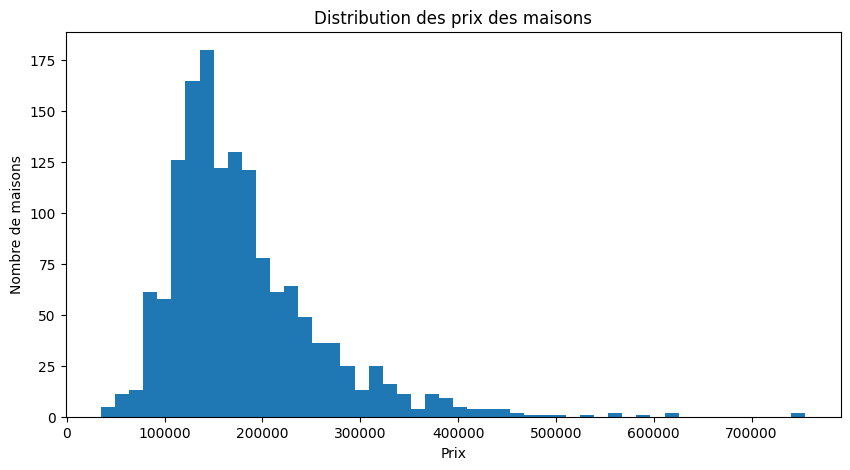

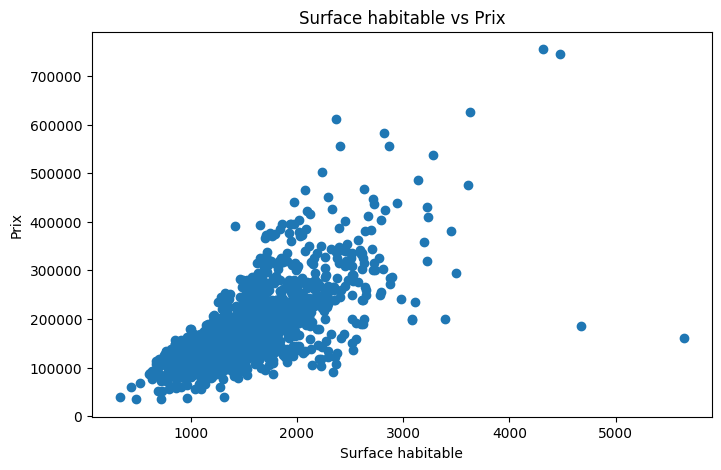

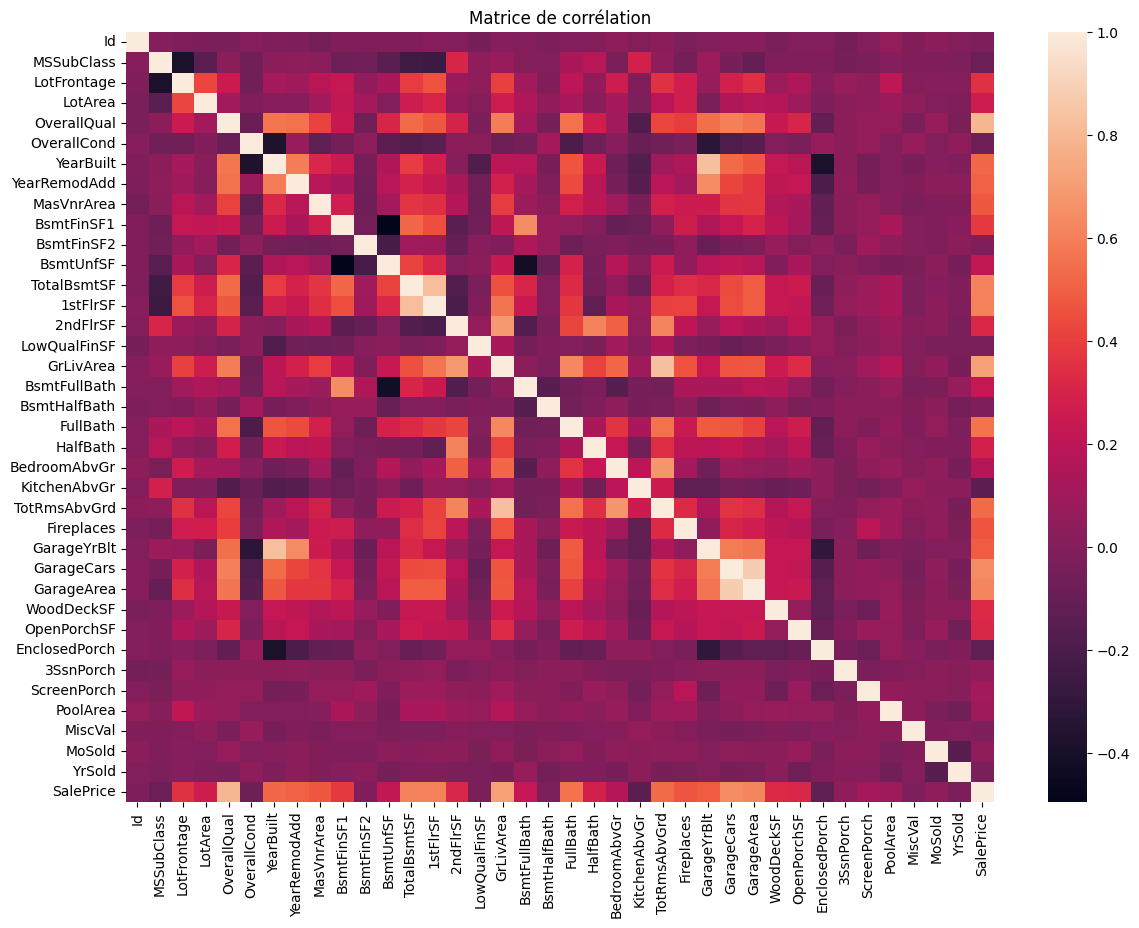

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


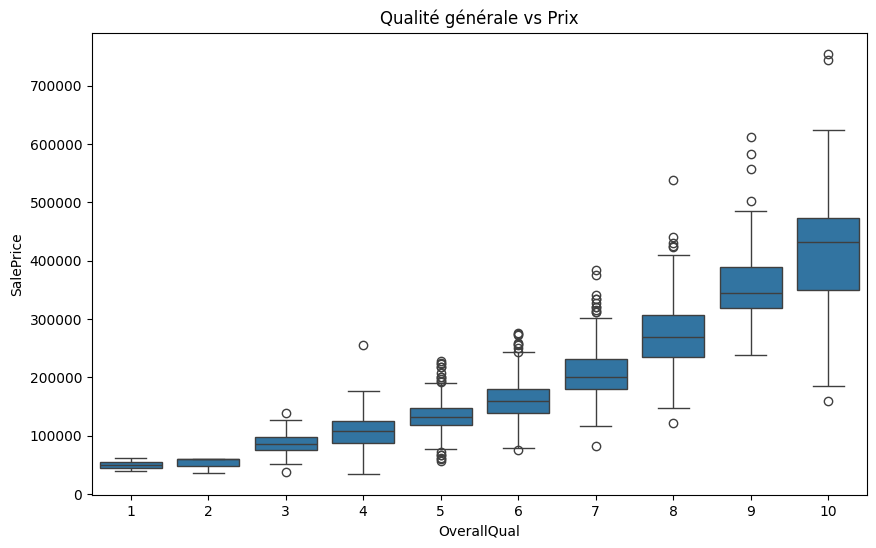

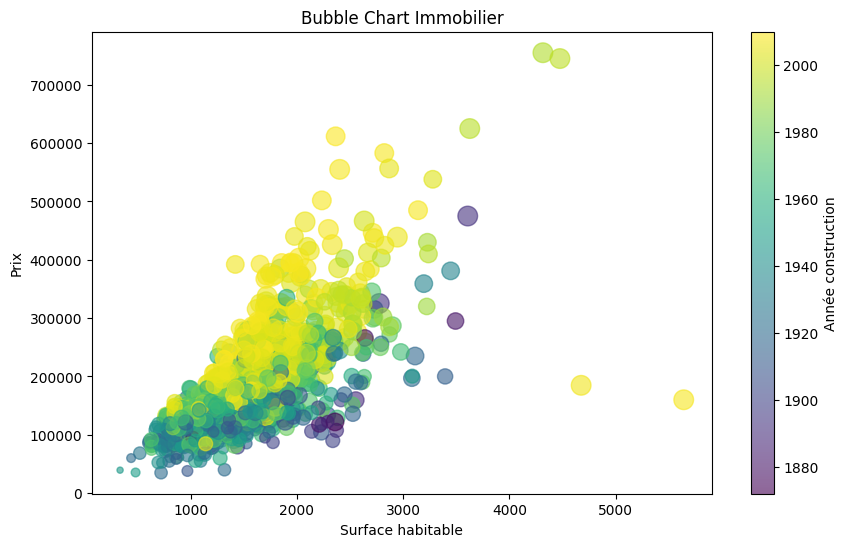

In [4]:
import pandas as pd
import os
import zipfile

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# DOWNLOAD DATASET
# ==============================

os.system(
    "kaggle competitions download -c house-prices-advanced-regression-techniques"
)

# ==============================
# EXTRACTION ZIP
# ==============================

with zipfile.ZipFile(
    "house-prices-advanced-regression-techniques.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("data/raw")

# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv("data/raw/train.csv")

# aperçu dataset
df.head()


# ==============================
# DISTRIBUTION DES PRIX
# ==============================

plt.figure(figsize=(10,5))

plt.hist(df["SalePrice"], bins=50)

plt.title("Distribution des prix des maisons")
plt.xlabel("Prix")
plt.ylabel("Nombre de maisons")

plt.show()


# ==============================
# SURFACE VS PRIX
# ==============================

plt.figure(figsize=(8,5))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"]
)

plt.title("Surface habitable vs Prix")
plt.xlabel("Surface habitable")
plt.ylabel("Prix")

plt.show()


# ==============================
# HEATMAP CORRÉLATIONS
# ==============================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(corr)

plt.title("Matrice de corrélation")

plt.show()


# ==============================
# VARIABLES LES PLUS CORRÉLÉES
# ==============================

top_corr = corr["SalePrice"].sort_values(
    ascending=False
)

print(top_corr.head(10))


# ==============================
# QUALITÉ VS PRIX
# ==============================

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["OverallQual"],
    y=df["SalePrice"]
)

plt.title("Qualité générale vs Prix")

plt.show()


# ==============================
# BUBBLE CHART
# ==============================

plt.figure(figsize=(10,6))

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],

    s=df["OverallQual"] * 20,

    c=df["YearBuilt"],

    alpha=0.6
)

plt.xlabel("Surface habitable")
plt.ylabel("Prix")

plt.title("Bubble Chart Immobilier")

plt.colorbar(label="Année construction")

plt.show()